# Parameters

In [2]:
show_intermediate_results = True

# Preparations

## Imports

In [3]:
import polars as pl

playlists = pl.scan_parquet('../processed_data/data_playlist_metadata.parquet')
playlist_tracks = pl.scan_parquet('../processed_data/data_playlist_songs.parquet')
tracks = pl.scan_parquet('../processed_data/data_song_metadata.parquet')

## Source Data

In [4]:
playlists.collect() if show_intermediate_results else None

playlist.id,playlist.name,owner.id,owner.name,playlist.extracted_date,playlist.region,playlist.country,playlist.is_social_set,owner.is_wcs_dj,song_count,artist_count
str,str,str,str,list[str],enum,enum,bool,bool,u32,u32
"""000PP6yV32HhGWZ8NkD7Jd""","""Joensuu""","""mjannis""","""Jannis Makropulos""",[],null,null,false,false,45,42
"""000QVDaEeEmfVJpfddp611""","""Songs with Swing/Blues Shuffle…","""wcsdunedin""","""WCSMelbourne""",[],"""Oceania""","""Australia""",false,false,397,327
"""000hjS5mHvPqB6B9kD46zc""","""WSNW '25 Saturday 03:00""","""1185428002""","""Kasia Stepek""",[],"""Europe""","""Poland""",false,true,26,25
"""001F19s2D2jzePZL6kmqYM""","""SAT, 4-DEC""","""angelabehnken""","""angelabehnken""",[],null,null,false,false,12,12
"""001eKsoK3IlnY35gLuLgaC""","""🌾🌄""","""amrosso22""","""Aubrey Rosso""",[],null,null,false,false,36,17
…,…,…,…,…,…,…,…,…,…,…
"""7zxTNmWpBgXQAYpVdpqf0i""","""old pop""","""1185428002""","""Kasia Stepek""",[],"""Europe""","""Poland""",false,true,55,47
"""7zy99M6oThI8U6AqiQsoru""","""old pop""","""1185428002""","""Kasia Stepek""",[],"""Europe""","""Poland""",false,true,86,69
"""7zyfGCIIBfSpHGPMGeCP8l""","""Mel's Teaching WCS Blues Playl…","""1272924841""","""Melissa Oh Yay""",[],null,null,false,false,60,53


In [5]:
playlist_tracks.collect() if show_intermediate_results else None

playlist.id,track.id,playlist_track.number,playlist_track.added_at
str,str,u16,date
"""000PP6yV32HhGWZ8NkD7Jd""","""03fyqQvwyhtTZQXWwBUNwm""",3,2012-09-22
"""000PP6yV32HhGWZ8NkD7Jd""","""05te51jEM1sj7wil6zVG2d""",10,2012-09-22
"""000PP6yV32HhGWZ8NkD7Jd""","""06udcdc729yctkGfZesfJ8""",42,2012-09-22
"""000PP6yV32HhGWZ8NkD7Jd""","""0BPGGNrTH34lp4nd2pQAC3""",4,2012-09-22
"""000PP6yV32HhGWZ8NkD7Jd""","""0HKHnVyxdzXPtg0LO6VrdM""",19,2012-09-22
…,…,…,…
"""new_1STEVaw1av8Fp9LtAzQMdt""","""7yXPZrrOzhYrZ3whWLxFXb""",1346,2024-02-08
"""new_1STEVaw1av8Fp9LtAzQMdt""","""7yYkpuZnIw4HQVSe7YHfWY""",95,2022-04-26
"""new_1STEVaw1av8Fp9LtAzQMdt""","""7yuUGBXakKjMjQnQssIP4I""",109,2022-06-24


In [6]:
tracks.collect()  if show_intermediate_results else None

track.id,track.name,track.artists,track.album.release_date,track.region,track.country,track.artists.name,track.artists.is_queer_artist,track.artists.is_poc_artist,track.bpm,playlist_count,dj_count
str,str,list[str],date,list[enum],list[enum],str,bool,bool,u8,u32,u32
null,"""Slow Train""","[""Boots Randolph"", """", … ""Language Transfer - The Thinking Method""]",null,"[""Asia"", ""Europe"", … ""Oceania""]","[""Australia"", ""Austria"", … ""USA""]","""Boots Randolph, , Ebrahim, Jes…",true,true,null,null,null
"""000CC8EParg64OmTxVnZ0p""","""It's All Coming Back To Me Now…","[""Glee Cast""]",2021-02-11,[],[],"""Glee Cast""",false,false,null,2,2
"""000N4CJL8IjQ0f2I4grgBO""","""Girl Next Door""","[""Ayra Starr"", ""Tyla""]",2023-05-11,"[""Asia"", ""North America""]","[""Singapore"", ""USA""]","""Ayra Starr, Tyla""",false,true,null,5,5
"""000TJlEJQ3nafsm1hBWpoj""","""LEMONHEAD (feat. 42 Dugg)""","[""42 Dugg"", ""Tyler, The Creator""]",2023-03-31,[],[],"""42 Dugg, Tyler, The Creator""",true,false,null,2,2
"""000uPbEAb9tlFkCJ1DIOcw""","""Kom""","[""Timoteij""]",2010-04-28,[],[],"""Timoteij""",false,false,null,7,6
…,…,…,…,…,…,…,…,…,…,…,…
"""7zz9QVNTgmN8zuIi7x0CCW""","""An Ancient Call""","[""Olivier Deriviere""]",2019-09-09,"[""North America""]","[""USA""]","""Olivier Deriviere""",false,false,null,2,2
"""7zzFMgUlCC0ZUQGXkf6t1B""","""Lonely""","[""Chloe x Halle""]",2020-06-12,"[""North America""]","[""USA""]","""Chloe x Halle""",false,false,null,8,6
"""7zzURURBrOxe9A9JAhpCnp""","""Ella Es""","[""Tony Vega""]",1994-01-01,"[""Europe"", ""North America""]","[""Germany"", ""USA""]","""Tony Vega""",false,false,null,2,1


# Analysis

## Tokenization

In [7]:
def tokenize(expr: pl.Expr) -> pl.Expr:
    return expr.str.to_lowercase().str.split(' ')

def tokenize_unique(expr: pl.Expr) -> pl.Expr:
    return tokenize(expr)\
        .list.filter(pl.element().ne(''))\
        .list.unique(maintain_order=True)

## Keyword statistics

Step 1: Tokenize the playlist names by splitting on whitespaces.

We currently turn every word into its own separate keyword term.
As a later optimization, it might make sense to treat words most often
occuring together (e.g. `late night`) to make the output more useful.

In [8]:
playlists_tokenized = playlists.select(
    pl.col('playlist.id'),
    pl.col('playlist.name'),
    pl.col('playlist.name').pipe(tokenize_unique).alias('unique_terms'),
)

playlists_tokenized.collect(engine='streaming') if show_intermediate_results else None

playlist.id,playlist.name,unique_terms
str,str,list[str]
"""000PP6yV32HhGWZ8NkD7Jd""","""Joensuu""","[""joensuu""]"
"""000QVDaEeEmfVJpfddp611""","""Songs with Swing/Blues Shuffle…","[""songs"", ""with"", … ""timing""]"
"""000hjS5mHvPqB6B9kD46zc""","""WSNW '25 Saturday 03:00""","[""wsnw"", ""'25"", … ""03:00""]"
"""001F19s2D2jzePZL6kmqYM""","""SAT, 4-DEC""","[""sat,"", ""4-dec""]"
"""001eKsoK3IlnY35gLuLgaC""","""🌾🌄""","[""🌾🌄""]"
…,…,…
"""7zxTNmWpBgXQAYpVdpqf0i""","""old pop""","[""old"", ""pop""]"
"""7zy99M6oThI8U6AqiQsoru""","""old pop""","[""old"", ""pop""]"
"""7zyfGCIIBfSpHGPMGeCP8l""","""Mel's Teaching WCS Blues Playl…","[""mel's"", ""teaching"", … ""playlist""]"


Step 2: Aggregate over playlist terms

In [9]:
exploded_playlists_tokenized = playlists_tokenized\
    .explode('unique_terms')\
    .rename({'unique_terms': 'term'})

exploded_playlists_tokenized.limit(100).collect(engine='streaming') if show_intermediate_results else None

playlist.id,playlist.name,term
str,str,str
"""000PP6yV32HhGWZ8NkD7Jd""","""Joensuu""","""joensuu"""
"""000QVDaEeEmfVJpfddp611""","""Songs with Swing/Blues Shuffle…","""songs"""
"""000QVDaEeEmfVJpfddp611""","""Songs with Swing/Blues Shuffle…","""with"""
"""000QVDaEeEmfVJpfddp611""","""Songs with Swing/Blues Shuffle…","""swing/blues"""
"""000QVDaEeEmfVJpfddp611""","""Songs with Swing/Blues Shuffle…","""shuffle"""
…,…,…
"""00BrxSphwuS0d6xb4iI0b5""","""Best WCS by BPM Old""","""wcs"""
"""00BrxSphwuS0d6xb4iI0b5""","""Best WCS by BPM Old""","""by"""
"""00BrxSphwuS0d6xb4iI0b5""","""Best WCS by BPM Old""","""bpm"""


In [10]:
tokens = exploded_playlists_tokenized\
    .group_by('term')\
    .agg(pl.col('term').count().alias('playlist_count'))\
    .sort('playlist_count', descending=True)

Review query plan for potential performance/memory problems:

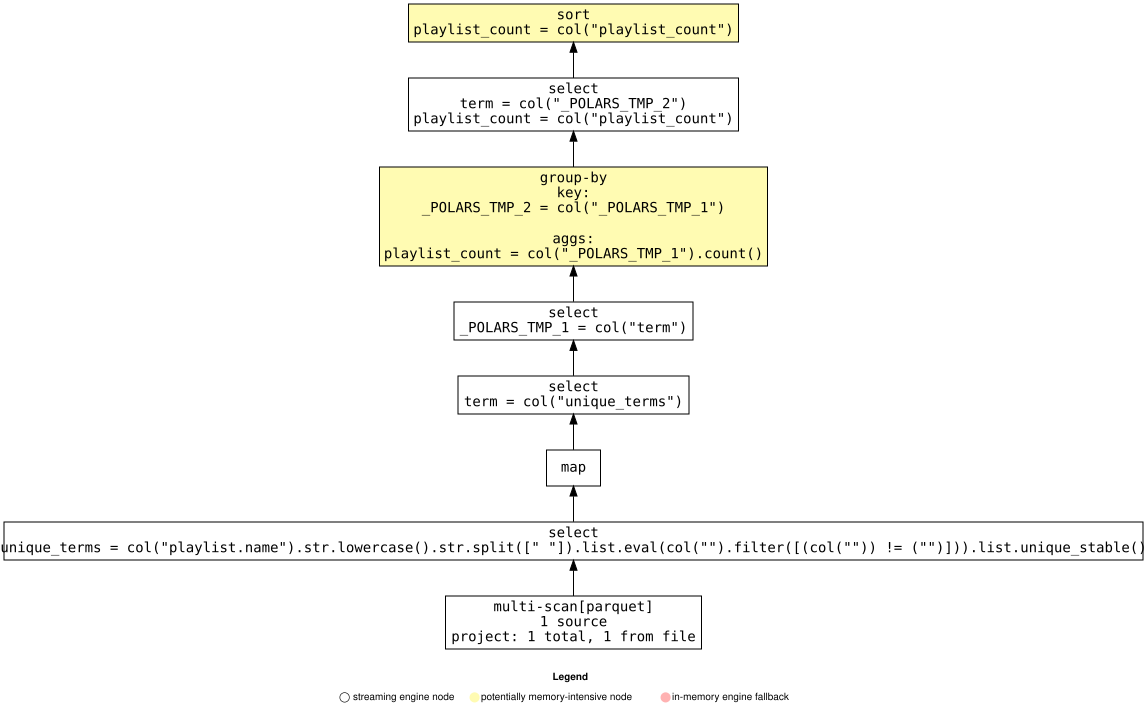

In [11]:
tokens.show_graph(plan_stage='physical', engine='streaming', optimized=True)

In [12]:
tokens.filter(pl.col('playlist_count').ge(100)).collect(engine='streaming')

term,playlist_count
str,u32
"""wcs""",14539
"""-""",6276
"""swing""",2652
"""blues""",1961
"""bpm""",1957
…,…
"""mar""",102
"""intermediate""",102
"""finals""",102


In [13]:
# Write to CSV
# tokens.filter(pl.col('playlist_count').ge(20)).sink_csv('playlist_keywords.csv', engine='streaming')

The following discoveries where made when manually reviewing the CSV data:

- Also split on & remove common punctuation (`(`, `)`, `[`, `]`,`:`, `#` etc.)
- Remove certain common words that do not provide any information:
  - on
  - by
  - with
  - at
  - and
  - a
  - I
  - ...
- Unify `90's`/`90s` etc.
- Unify `bday`/`birthday`/`b-day` etc.
- Check correlations between consecutive words

## Keyword <=> Song correlations

Ignore tokens that appear only a few types to reduce the size of the `join`/`group_by`.

In [14]:
tokens\
    .filter(pl.col('playlist_count').le(5))\
    .group_by(pl.col('playlist_count').alias('max_playlist_count'))\
    .agg(pl.col('playlist_count').count().alias('num_terms'))\
    .sort('max_playlist_count')\
    .collect(engine='streaming')

max_playlist_count,num_terms
u32,u32
0,1
1,30813
2,5803
3,2345
4,1293
5,845


In [15]:
relevant_tokens = tokens\
    .filter(pl.col('playlist_count').ge(5))\
    .collect(engine='streaming')

track_keywords = playlist_tracks\
    .join(exploded_playlists_tokenized.join(relevant_tokens.lazy(), how='semi', on='term'), how='inner', on='playlist.id')\
    .group_by('track.id', 'term')\
    .agg(pl.col('term').count().alias('playlist_count'))

track_keywords.limit(50).collect(engine='streaming')

track.id,term,playlist_count
str,str,u32
"""4RnYdQyGBAW9a9647kA09W""","""my""",6
"""0COqiPhxzoWICwFCS4eZcp""","""my""",16
"""0DjsmSBheOderptDDHvL5C""","""my""",191
"""0ENr5Ag6K1TKG7AcMtCPMT""","""shazam""",88
"""0G4RDccI3c7cW5CxT5KUlw""","""my""",55
…,…,…
"""1eV2FGbbyxCJ6xaLqBRiFW""","""my""",56
"""1etcoCl2mkHpMHkMVco8iz""","""tracks""",23
"""1fiDe8sb2DMEU4JGPOIEB1""","""my""",6


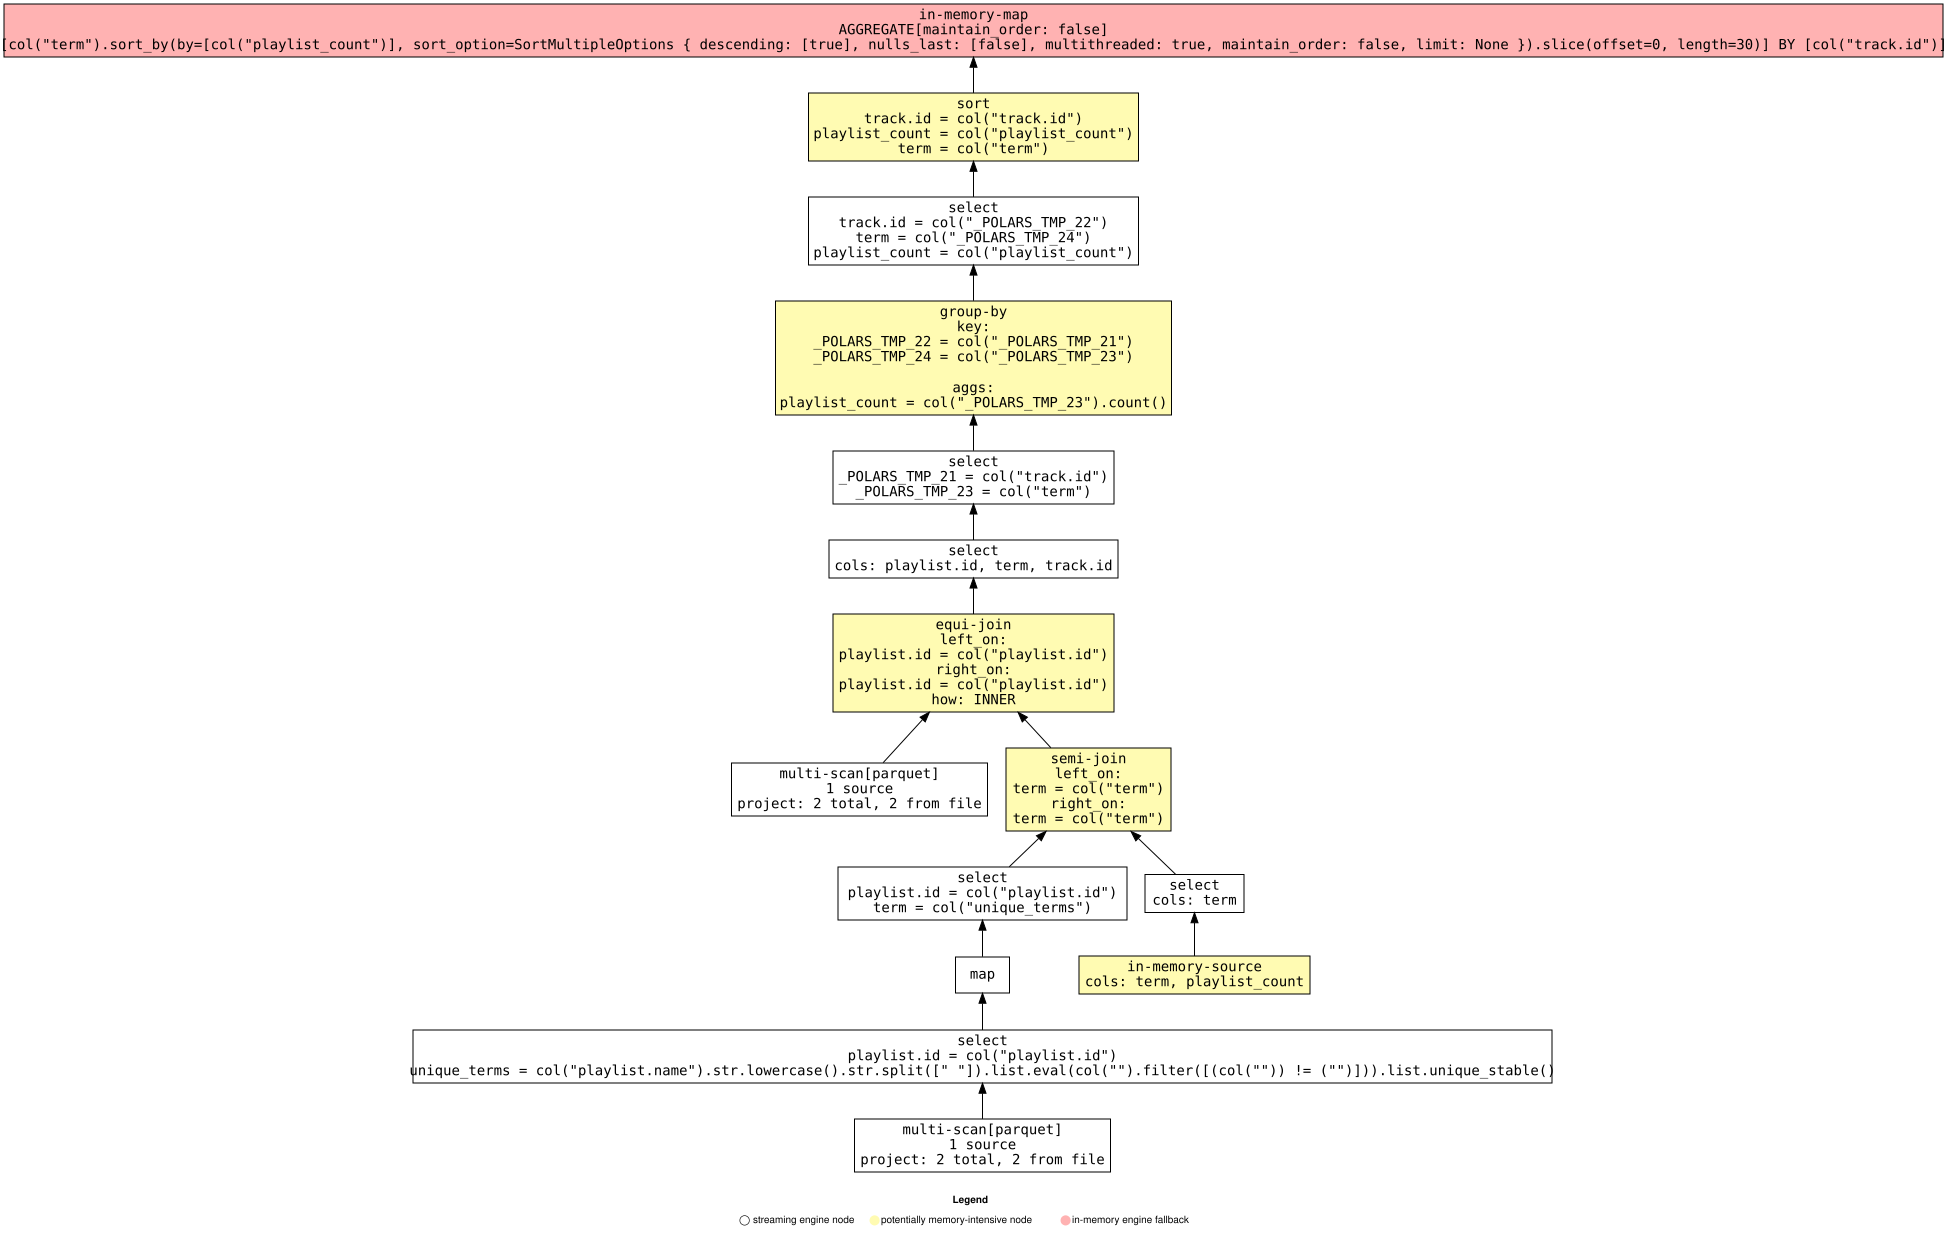

In [16]:
q = track_keywords\
    .sort('track.id', 'playlist_count', 'term')\
    .group_by('track.id')\
    .agg(pl.col('term').sort_by('playlist_count', descending=True).head(30))

q.show_graph(plan_stage='physical', engine='streaming', optimized=True)

In [23]:
# q = track_keywords\
#     .sort('track.id', 'playlist_count', 'term')\
#     .group_by('track.id')\
#     .agg(pl.col('term').first())

q = track_keywords.count()

# q.show_graph(plan_stage='physical', engine='streaming', optimized=True)

q.collect()

track.id,term,playlist_count
u32,u32,u32
4552852,4552852,4552852


In [ ]:
temp_file = 'temp_track_keywords.parquet'
track_keywords.sink_parquet(temp_file)
track_keywords = pl.scan_parquet(temp_file)

In [26]:
temp_file = 'temp_track_keywords_by_track_id.parquet'
track_keywords_by_track_id = track_keywords.sort('track.id')
track_keywords_by_track_id.sink_parquet(temp_file)
track_keywords_by_track_id = pl.scan_parquet(temp_file)

In [36]:
track_keywords_grouped_by_track_id = track_keywords_by_track_id\
    .join(tracks.slice(20, 20).cache(), how='semi', on='track.id')\
    .group_by('track.id')\
    .agg(pl.col('term').sort_by('playlist_count', descending=True).head(20),
         pl.col('playlist_count').sort(descending=True).head(20).alias('playlist_counts'),
         pl.col('playlist_count').sort(descending=True).head(20).sum())\
    .join(tracks.select('track.id', 'track.name', 'track.artists'), how='inner', on='track.id')

# track_keywords_grouped_by_track_id.show_graph(plan_stage='physical', engine='streaming', optimized=True)
track_keywords_grouped_by_track_id.collect()

track.id,term,playlist_counts,playlist_count,track.name,track.artists
str,list[str],list[u32],u32,str,list[str]
"""002pgO1R2952phPuujFoOE""","[""wcs"", ""-"", … ""party""]","[96, 19, … 5]",268,"""WOW""","[""Zara Larsson""]"
"""002wNT6cMCf0N93MUC1fwM""","[""wcs"", ""intro"", … ""dj""]","[5, 2, … 1]",25,"""Alone""","[""Will Gittens""]"
"""0032P9X3AD4AQvN7yzpmTo""","[""west"", ""coast"", … ""fusion""]","[3, 3, … 1]",26,"""Middle""","[""Jessame"", ""Sean Turk""]"
"""0037eQ5YPvX3aHBrLGVmB9""","[""120-125"", ""-"", … ""wcs""]","[2, 2, … 2]",14,"""The Day After You Said Goodbye""","[""SURAN""]"
"""003CBfF5s2kwaGSdJt3WkQ""","[""wasda"", ""❤️"", … ""fast""]","[3, 2, … 1]",30,"""BOOTS 'N ALL""","[""Kaylee Bell""]"
…,…,…,…,…,…
"""004HWXFltpet1VoUuRW4Om""","[""iii"", ""of"", … ""the""]","[1, 1, … 1]",4,"""Fireflower""","[""jeremy messersmith""]"
"""004LyfCBQmqMcg8QD0zpbR""","[""wcs"", ""-"", … ""sortieren""]","[3, 1, … 1]",16,"""Mexico""","[""Gamma Skies"", ""Amaranthine""]"
"""004XT7kCZUEJkVIZjmBdDi""","[""the"", ""dance"", … ""smoke""]","[1, 1, … 1]",6,"""Life Rolls On""","[""Slightly Stoopid""]"


In [29]:
track_keywords_by_track_id\
    .join(tracks.limit(20), how='semi', on='track.id')\
    .count()\
    .collect(engine='streaming')

track.id,term,playlist_count
u32,u32,u32
1240,1240,1240
